# Sprite 8/9 Low-Level PNG Analysis

This notebook compares `datasets/animals/sprite_0.png` through `sprite_9.png`, with a focus on whether sprites `8-9` differ from sprites `0-7` in low-level ways that could affect RPL training on orientation and rotation speed.

The checks cover:

- PNG container chunks and decoded Pillow metadata.
- Raw transparent-pixel RGB values.
- The exact RGB+alpha tensor created by the project loaders.
- Alpha-mask statistics, edge softness, border contact, and bounding boxes.
- Rotation/render-time artifacts after the same Kornia affine path used by `SpriteVideoDataset`.

Main hypothesis to test: sprites `8-9` were exported through a different pipeline and have hard binary alpha masks, while sprites `0-7` have antialiased soft alpha masks.


In [1]:
from pathlib import Path
import math
import struct
import subprocess
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

try:
    import torch
    import kornia as K
except Exception as exc:
    torch = None
    K = None
    warnings.warn(f"Torch/Kornia unavailable; render-time cells will be skipped: {exc}")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SPRITE_DIR = PROJECT_ROOT / "datasets" / "animals"
SPRITE_PATHS = sorted(SPRITE_DIR.glob("sprite_*.png"), key=lambda p: int(p.stem.split("_")[1]))

assert SPRITE_PATHS, f"No sprite_*.png files found in {SPRITE_DIR}"
print(f"Project root: {PROJECT_ROOT}")
print(f"Found {len(SPRITE_PATHS)} sprites in {SPRITE_DIR}")


Project root: /Users/matushalak/Documents/harpl
Found 10 sprites in /Users/matushalak/Documents/harpl/datasets/animals


## Helper Functions

The loader helpers below intentionally mirror `SpriteVideoDataset._pil_to_tensor` and `AttentionSpritesDataset._load_sprite_tensor`: RGBA is composited onto black using alpha, then stored as RGB plus a separate alpha channel.


In [2]:
def sprite_idx(path: Path) -> int:
    return int(path.stem.split("_")[1])


def read_png_chunks(path: Path):
    data = path.read_bytes()
    assert data.startswith(b"\x89PNG\r\n\x1a\n"), f"Not a PNG: {path}"
    chunks = []
    offset = 8
    while offset < len(data):
        length = struct.unpack(">I", data[offset:offset + 4])[0]
        chunk_type = data[offset + 4:offset + 8].decode("latin1")
        chunks.append((chunk_type, length))
        offset += 12 + length
    return chunks


def load_rgba(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGBA"))


def load_loader_tensor_np(path: Path) -> np.ndarray:
    """Return [4, H, W] RGB+alpha exactly as the project loaders create it."""
    pil_img = Image.open(path).convert("RGBA")
    alpha = pil_img.split()[3]
    rgb = Image.new("RGB", pil_img.size, (0, 0, 0))
    rgb.paste(pil_img, mask=alpha)

    rgb_np = np.asarray(rgb, dtype=np.float32) / 255.0
    alpha_np = np.asarray(alpha, dtype=np.float32) / 255.0
    return np.concatenate([rgb_np.transpose(2, 0, 1), alpha_np[None]], axis=0)


def transparent_rgb_summary(rgba: np.ndarray):
    transparent = rgba[..., 3] == 0
    if not transparent.any():
        return [], 0, 0
    rgb = rgba[..., :3][transparent]
    uniq = np.unique(rgb, axis=0)
    nonzero = int((rgb.sum(axis=1) > 0).sum())
    return uniq.tolist(), len(uniq), nonzero


def total_variation(x: np.ndarray) -> float:
    return float(np.abs(np.diff(x, axis=-2)).mean() + np.abs(np.diff(x, axis=-1)).mean())


def laplacian_energy(x: np.ndarray) -> float:
    center = x[..., 1:-1, 1:-1]
    lap = 4 * center - x[..., :-2, 1:-1] - x[..., 2:, 1:-1] - x[..., 1:-1, :-2] - x[..., 1:-1, 2:]
    return float((lap ** 2).mean())


## PNG Container and Metadata

Sprites `0-7` carry an `iCCP` color-profile chunk; sprites `8-9` do not. The project loaders decode with Pillow and do not pass PNG metadata to the network, so this is mostly evidence that the files came from different export pipelines.


In [3]:
container_rows = []
for path in SPRITE_PATHS:
    img = Image.open(path)
    chunks = read_png_chunks(path)
    container_rows.append({
        "sprite": sprite_idx(path),
        "file": path.name,
        "bytes": path.stat().st_size,
        "mode_after_open": img.mode,
        "size": img.size,
        "pillow_info_keys": tuple(sorted(img.info.keys())),
        "png_chunks": tuple(t for t, _ in chunks),
        "chunk_lengths": chunks,
        "has_iccp_chunk": any(t == "iCCP" for t, _ in chunks),
    })

container_df = pd.DataFrame(container_rows)
display(container_df)

display(container_df.groupby(container_df["sprite"].ge(8).map({False: "0-7", True: "8-9"}))["has_iccp_chunk"].value_counts())


,sprite,file,bytes,mode_after_open,size,pillow_info_keys,png_chunks,chunk_lengths,has_iccp_chunk
0,0,sprite_0.png,2495,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 2064), (IEND,...",True
1,1,sprite_1.png,2522,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 2091), (IEND,...",True
2,2,sprite_2.png,2955,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 2524), (IEND,...",True
3,3,sprite_3.png,1708,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 1277), (IEND,...",True
4,4,sprite_4.png,2386,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 1955), (IEND,...",True
5,5,sprite_5.png,2170,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 1739), (IEND,...",True
6,6,sprite_6.png,2126,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 1695), (IEND,...",True
7,7,sprite_7.png,2398,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 1967), (IEND,...",True
8,8,sprite_8.png,2082,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 1651), (IEND,...",True
9,9,sprite_9.png,2031,RGBA,"(32, 32)","(icc_profile,)","(IHDR, iCCP, IDAT, IEND)","[(IHDR, 13), (iCCP, 362), (IDAT, 1600), (IEND,...",True


sprite  has_iccp_chunk
0-7     True              8
8-9     True              2
Name: count, dtype: int64

## Decoded Pixel Statistics

This table compares raw RGBA data and the actual loader tensor. The most important columns are `partial_px` and `alpha_levels`: sprites `8-9` have no semi-transparent pixels and only binary alpha.


In [4]:
pixel_rows = []
for path in SPRITE_PATHS:
    idx = sprite_idx(path)
    rgba = load_rgba(path)
    loader = load_loader_tensor_np(path)
    rgb = rgba[..., :3].astype(np.float32)
    alpha = rgba[..., 3].astype(np.float32)
    loader_rgb = loader[:3].transpose(1, 2, 0)
    loader_alpha = loader[3]

    visible = alpha > 0
    opaque = alpha == 255
    partial = (alpha > 0) & (alpha < 255)
    transparent = alpha == 0
    ys, xs = np.where(visible)
    bbox = (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())) if len(xs) else None

    border = np.zeros_like(alpha, dtype=bool)
    border[0, :] = border[-1, :] = border[:, 0] = border[:, -1] = True
    transparent_rgb, transparent_unique_count, transparent_nonzero_px = transparent_rgb_summary(rgba)

    pixel_rows.append({
        "sprite": idx,
        "group": "8-9" if idx >= 8 else "0-7",
        "alpha_sum_px": alpha.sum() / 255.0,
        "visible_px": int(visible.sum()),
        "opaque_px": int(opaque.sum()),
        "partial_px": int(partial.sum()),
        "alpha_levels": int(len(np.unique(alpha))),
        "mean_alpha_visible": float(alpha[visible].mean()) if visible.any() else np.nan,
        "bbox_xyxy": bbox,
        "border_visible_px": int((visible & border).sum()),
        "border_opaque_px": int((opaque & border).sum()),
        "border_partial_px": int((partial & border).sum()),
        "transparent_rgb_unique": transparent_rgb,
        "transparent_rgb_unique_count": transparent_unique_count,
        "transparent_rgb_nonzero_px": transparent_nonzero_px,
        "loader_transparent_rgb_nonzero_px": int((loader_rgb[transparent].sum(axis=1) > 0).sum()) if transparent.any() else 0,
        "raw_rgb_visible_mean": float(rgb[visible].mean() / 255.0) if visible.any() else np.nan,
        "loader_rgb_visible_mean": float(loader_rgb[visible].mean()) if visible.any() else np.nan,
        "raw_rgb_partial_mean": float(rgb[partial].mean() / 255.0) if partial.any() else np.nan,
        "loader_rgb_partial_mean": float(loader_rgb[partial].mean()) if partial.any() else np.nan,
        "loader_rgb_sum": float(loader_rgb.sum()),
        "loader_alpha_sum": float(loader_alpha.sum()),
    })

pixel_df = pd.DataFrame(pixel_rows)
display(pixel_df)

summary_cols = [
    "alpha_sum_px", "visible_px", "opaque_px", "partial_px", "alpha_levels",
    "mean_alpha_visible", "border_visible_px", "border_opaque_px", "border_partial_px",
    "transparent_rgb_unique_count", "transparent_rgb_nonzero_px",
    "loader_transparent_rgb_nonzero_px",
]
display(pixel_df.groupby("group")[summary_cols].agg(["mean", "min", "max"]))


,sprite,group,alpha_sum_px,visible_px,opaque_px,partial_px,alpha_levels,mean_alpha_visible,bbox_xyxy,border_visible_px,border_opaque_px,border_partial_px,transparent_rgb_unique,transparent_rgb_unique_count,transparent_rgb_nonzero_px,loader_transparent_rgb_nonzero_px,raw_rgb_visible_mean,loader_rgb_visible_mean,raw_rgb_partial_mean,loader_rgb_partial_mean,loader_rgb_sum,loader_alpha_sum
0,0,0-7,509.694122,615,393,222,107,211.336578,"(1, 0, 30, 31)",20,0,20,"[[0, 0, 0]]",1,0,0,0.414517,0.392114,0.123971,0.061909,723.450989,509.694092
1,1,0-7,545.439209,633,384,249,111,219.726700,"(0, 0, 30, 31)",22,0,22,"[[0, 0, 0]]",1,0,0,0.411897,0.407827,0.113794,0.103446,774.462769,545.439209
2,2,0-7,662.529419,779,430,349,139,216.874191,"(0, 0, 31, 31)",47,0,47,"[[0, 0, 0]]",1,0,0,0.285800,0.236860,0.196670,0.087432,553.541199,662.529419
3,3,0-7,332.478424,388,219,169,93,218.510315,"(0, 6, 30, 26)",2,0,2,"[[0, 0, 0]]",1,0,0,0.363112,0.361455,0.078462,0.074657,420.733368,332.478424
4,4,0-7,592.854919,666,444,222,112,226.993988,"(0, 1, 30, 30)",6,0,6,"[[0, 0, 0]]",1,0,0,0.343542,0.342978,0.033592,0.031902,685.270630,592.854980
5,5,0-7,600.121582,671,460,211,103,228.064087,"(0, 0, 30, 31)",27,0,27,"[[0, 0, 0]]",1,0,0,0.574211,0.563843,0.125645,0.092674,1135.015625,600.121582
6,6,0-7,556.184326,618,427,191,98,229.493530,"(1, 1, 29, 31)",13,0,13,"[[0, 0, 0]]",1,0,0,0.479730,0.476299,0.070622,0.059522,883.058838,556.184326
7,7,0-7,547.290222,627,350,277,114,222.582138,"(2, 0, 30, 31)",20,0,20,"[[0, 0, 0]]",1,0,0,0.387218,0.383530,0.117472,0.109124,721.419617,547.290222
8,8,8-9,577.360779,715,526,189,67,205.911880,"(0, 0, 31, 31)",34,0,34,"[[0, 0, 0]]",1,0,0,0.186248,0.186248,0.001418,0.001418,399.501984,577.360779
9,9,8-9,584.149048,676,366,310,96,220.352066,"(0, 1, 31, 29)",17,0,17,"[[0, 0, 0]]",1,0,0,0.370283,0.369631,0.062096,0.060675,749.611816,584.149048


alpha_sum_px                         visible_px           opaque_px           partial_px           alpha_levels          mean_alpha_visible                         border_visible_px          \
              mean         min         max       mean  min  max      mean  min  max       mean  min  max         mean min  max               mean         min         max              mean min max   
group                                                                                                                                                                                                 
0-7     543.324036  332.478424  662.529419    624.625  388  779   388.375  219  460     236.25  169  349      109.625  93  139         221.697691  211.336578  229.493530            19.625   2  47   
8-9     580.754883  577.360779  584.149048    695.500  676  715   446.000  366  526     249.50  189  310       81.500  67   96         213.131973  205.911880  220.352066            25.500  17  34   

      border_opaque_px         border_partial_px         transparent_rgb_unique_count         transparent_rgb_nonzero_px         loader_transparent_rgb_nonzero_px          
                  mean min max              mean min max                         mean min max                       mean min max                              mean min max  
group                                                                                                                                                                       
0-7                0.0   0   0            19.625   2  47                          1.0   1   1                        0.0   0   0                               0.0   0   0  
8-9                0.0   0   0            25.500  17  34                          1.0   1   1                        0.0   0   0                               0.0   0   0

## Sprite and Alpha Visualizations

Rows show: raw RGBA composited on a checkerboard, the loader-composited RGB image, and the alpha mask. The binary, hard-edged alpha masks of sprites `8-9` should stand out in the alpha row and histogram below.


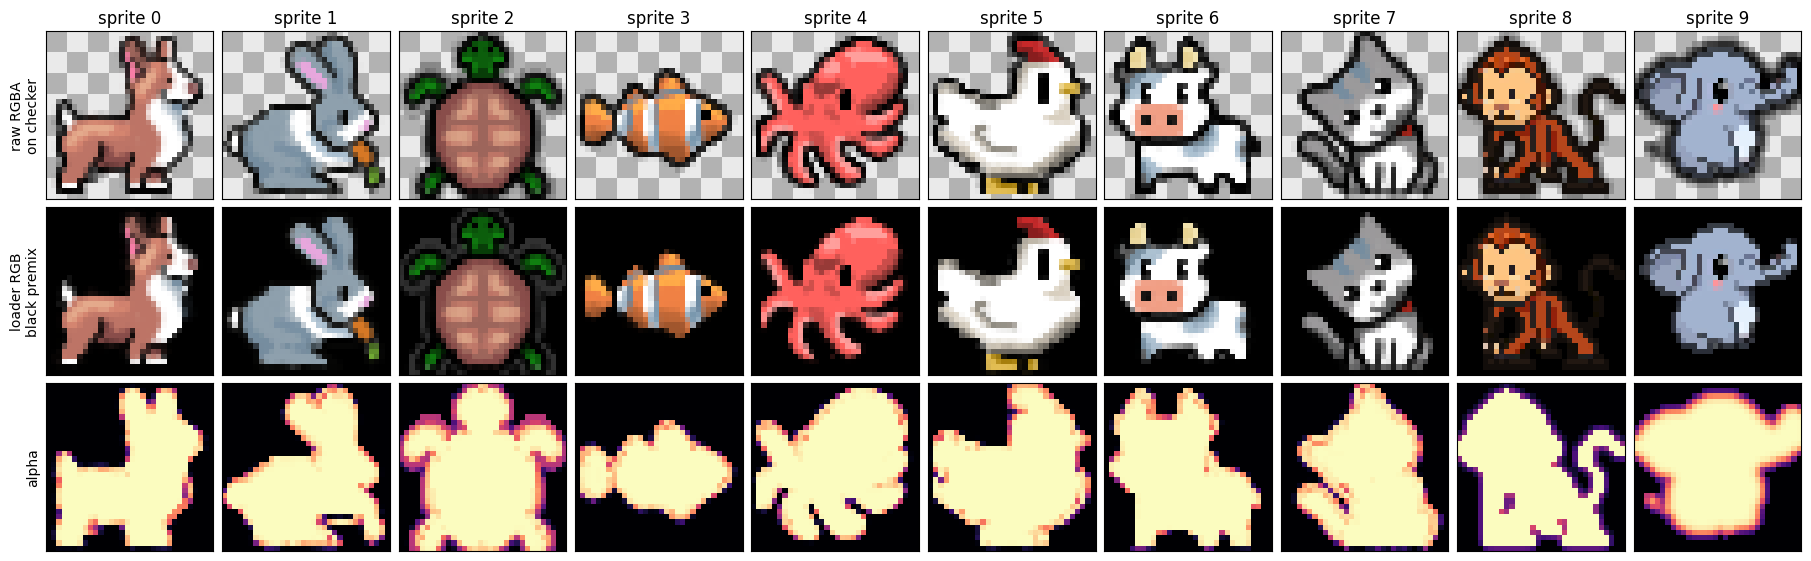

In [5]:
def checkerboard(size, tile=4, low=0.70, high=0.92):
    h, w = size
    yy, xx = np.indices((h, w))
    board = np.where(((yy // tile) + (xx // tile)) % 2 == 0, low, high)
    return np.repeat(board[..., None], 3, axis=2)


def composite_rgba_on_checker(rgba):
    rgb = rgba[..., :3].astype(np.float32) / 255.0
    alpha = rgba[..., 3:4].astype(np.float32) / 255.0
    bg = checkerboard(rgba.shape[:2])
    return alpha * rgb + (1 - alpha) * bg

fig, axes = plt.subplots(3, len(SPRITE_PATHS), figsize=(18, 5.5), constrained_layout=True)
for col, path in enumerate(SPRITE_PATHS):
    rgba = load_rgba(path)
    loader = load_loader_tensor_np(path)
    loader_rgb = loader[:3].transpose(1, 2, 0)
    alpha = rgba[..., 3]

    axes[0, col].imshow(composite_rgba_on_checker(rgba), interpolation="nearest")
    axes[0, col].set_title(f"sprite {sprite_idx(path)}")
    axes[1, col].imshow(loader_rgb, interpolation="nearest")
    axes[2, col].imshow(alpha, cmap="magma", vmin=0, vmax=255, interpolation="nearest")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

axes[0, 0].set_ylabel("raw RGBA\non checker")
axes[1, 0].set_ylabel("loader RGB\nblack premix")
axes[2, 0].set_ylabel("alpha")
plt.show()


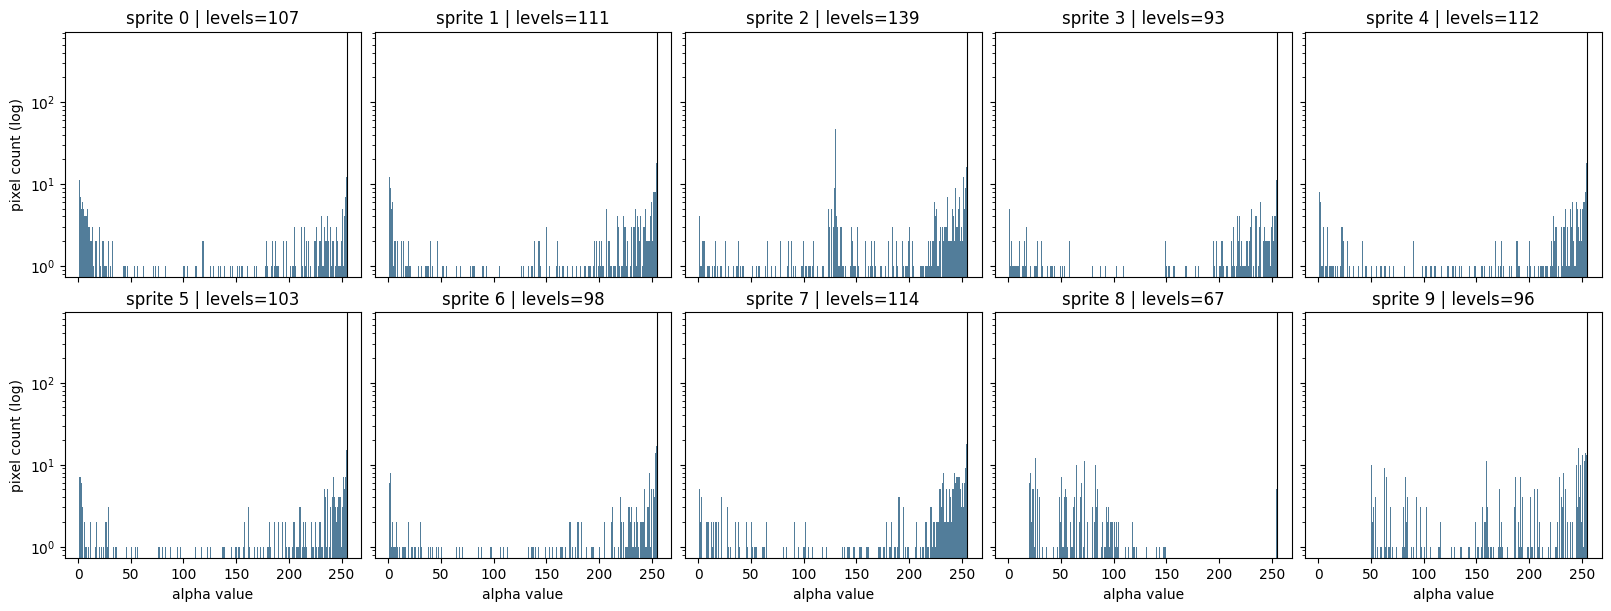

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True, sharey=True, constrained_layout=True)
bins = np.arange(257)
for ax, path in zip(axes.ravel(), SPRITE_PATHS):
    alpha = load_rgba(path)[..., 3]
    vals = alpha[alpha > 0]
    ax.hist(vals, bins=bins, color="#3f6f8f", alpha=0.9)
    ax.set_title(f"sprite {sprite_idx(path)} | levels={len(np.unique(alpha))}")
    ax.set_yscale("log")
    ax.axvline(255, color="black", lw=0.8)

for ax in axes[-1, :]:
    ax.set_xlabel("alpha value")
for ax in axes[:, 0]:
    ax.set_ylabel("pixel count (log)")
plt.show()


## Hidden Transparent RGB

Raw PNGs `8-9` have white RGB values under fully transparent pixels, while `0-7` have black. In the current project loaders this is eliminated because sprites are composited onto black before the affine transform. If another code path reads straight RGBA channels directly, this would become a major invisible cue.


,sprite,group,transparent_rgb_unique,transparent_rgb_nonzero_px,loader_transparent_rgb_nonzero_px
0,0,0-7,"[[0, 0, 0]]",0,0
1,1,0-7,"[[0, 0, 0]]",0,0
2,2,0-7,"[[0, 0, 0]]",0,0
3,3,0-7,"[[0, 0, 0]]",0,0
4,4,0-7,"[[0, 0, 0]]",0,0
5,5,0-7,"[[0, 0, 0]]",0,0
6,6,0-7,"[[0, 0, 0]]",0,0
7,7,0-7,"[[0, 0, 0]]",0,0
8,8,8-9,"[[0, 0, 0]]",0,0
9,9,8-9,"[[0, 0, 0]]",0,0


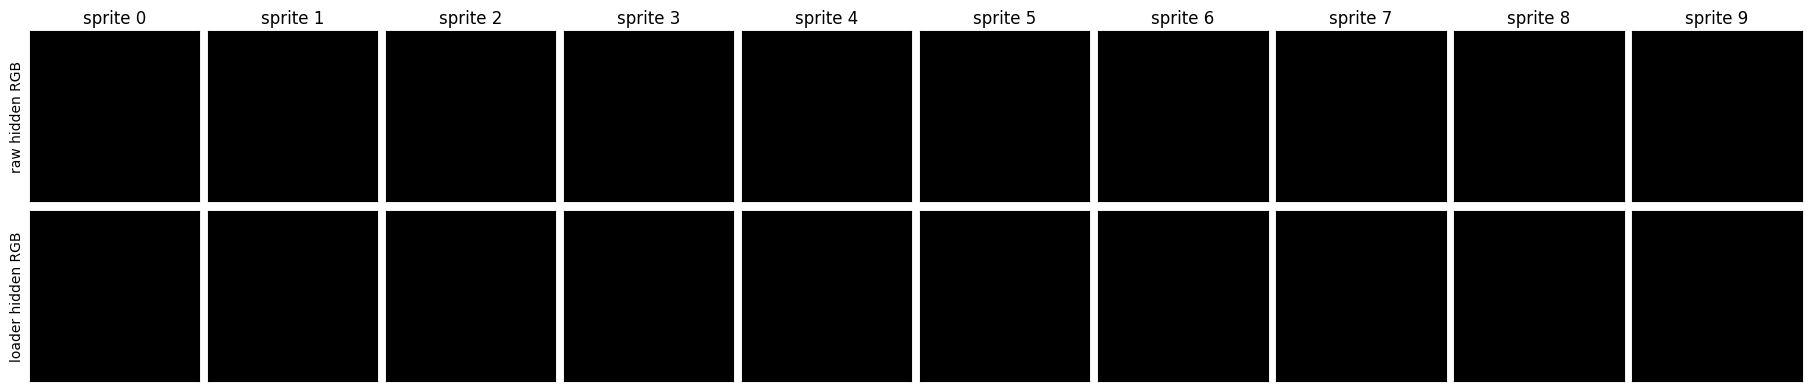

In [7]:
hidden_rgb_df = pixel_df[[
    "sprite", "group", "transparent_rgb_unique", "transparent_rgb_nonzero_px", "loader_transparent_rgb_nonzero_px"
]].copy()
display(hidden_rgb_df)

fig, axes = plt.subplots(2, len(SPRITE_PATHS), figsize=(18, 3.8), constrained_layout=True)
for col, path in enumerate(SPRITE_PATHS):
    rgba = load_rgba(path)
    transparent = rgba[..., 3] == 0
    raw_rgb = rgba[..., :3].astype(np.float32) / 255.0
    loader_rgb = load_loader_tensor_np(path)[:3].transpose(1, 2, 0)

    raw_vis = np.zeros_like(raw_rgb)
    raw_vis[transparent] = raw_rgb[transparent]
    loader_vis = np.zeros_like(loader_rgb)
    loader_vis[transparent] = loader_rgb[transparent]

    axes[0, col].imshow(raw_vis, interpolation="nearest", vmin=0, vmax=1)
    axes[0, col].set_title(f"sprite {sprite_idx(path)}")
    axes[1, col].imshow(loader_vis, interpolation="nearest", vmin=0, vmax=1)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axes[0, 0].set_ylabel("raw hidden RGB")
axes[1, 0].set_ylabel("loader hidden RGB")
plt.show()


## Render-Time Rotation Probe

This reproduces the important part of `SpriteVideoDataset._create_video`: duplicate the sprite, apply Kornia `warp_affine` with rotation, extract RGB+alpha, and alpha-composite onto a gray background.

Why this matters: hard binary masks become staircase-like after rotation. Soft masks remain more stable. The metrics below quantify how much alpha support, frame mean, edge energy, and Laplacian energy vary over angle.


In [8]:
def render_sprite_batch(path: Path, angles_deg, output_size=(64, 64), position=(32, 32), scale=1.0):
    if torch is None or K is None:
        raise RuntimeError("Torch/Kornia are unavailable in this kernel.")

    sprite = torch.from_numpy(load_loader_tensor_np(path)).float()
    batch_size = len(angles_deg)
    imgs = sprite.unsqueeze(0).repeat(batch_size, 1, 1, 1)
    _, _, img_h, img_w = imgs.shape
    center_x, center_y = img_w / 2, img_h / 2

    rotations = torch.tensor(angles_deg, dtype=torch.float32)
    scales = torch.full((batch_size,), float(scale), dtype=torch.float32)
    positions = torch.tensor([position] * batch_size, dtype=torch.float32)

    angles_rad = rotations * (math.pi / 180.0)
    cos_angles = torch.cos(angles_rad)
    sin_angles = torch.sin(angles_rad)

    matrices = torch.zeros(batch_size, 2, 3)
    matrices[:, 0, 0] = cos_angles * scales
    matrices[:, 0, 1] = -sin_angles * scales
    matrices[:, 1, 0] = sin_angles * scales
    matrices[:, 1, 1] = cos_angles * scales
    matrices[:, 0, 2] = positions[:, 0] - (center_x * cos_angles * scales - center_y * sin_angles * scales)
    matrices[:, 1, 2] = positions[:, 1] - (center_x * sin_angles * scales + center_y * cos_angles * scales)

    transformed = K.geometry.transform.warp_affine(
        imgs,
        matrices,
        dsize=output_size,
        align_corners=True,
    )

    rgb = transformed[:, :3].numpy()
    alpha = transformed[:, 3:4].numpy()
    background = np.full_like(rgb, 0.5)
    frames = alpha * rgb + (1 - alpha) * background
    return frames, alpha


def render_metrics_for_sprite(path: Path, angles_deg=range(0, 360, 5)):
    frames, alpha = render_sprite_batch(path, list(angles_deg))
    lum = frames.mean(axis=1, keepdims=True)

    rows = []
    for angle, frame, a, y in zip(angles_deg, frames, alpha, lum):
        partial = (a > 1e-6) & (a < 1 - 1e-6)
        nonzero = a > 1e-6
        rows.append({
            "sprite": sprite_idx(path),
            "group": "8-9" if sprite_idx(path) >= 8 else "0-7",
            "angle": angle,
            "alpha_sum": float(a.sum()),
            "alpha_partial_px": int(partial.sum()),
            "alpha_nonzero_px": int(nonzero.sum()),
            "frame_mean": float(frame.mean()),
            "frame_std": float(frame.std()),
            "lum_total_variation": total_variation(y),
            "lum_laplacian_energy": laplacian_energy(y),
            "alpha_total_variation": total_variation(a),
            "alpha_laplacian_energy": laplacian_energy(a),
        })
    return pd.DataFrame(rows)

if torch is None or K is None:
    render_df = pd.DataFrame()
    print("Skipping render metrics because Torch/Kornia are unavailable.")
else:
    render_df = pd.concat([render_metrics_for_sprite(path) for path in SPRITE_PATHS], ignore_index=True)
    display(render_df.head())


,sprite,group,angle,alpha_sum,alpha_partial_px,alpha_nonzero_px,frame_mean,frame_std,lum_total_variation,lum_laplacian_energy,alpha_total_variation,alpha_laplacian_energy
0,0,0-7,0,509.694183,232,623,0.496310,0.112115,0.051347,0.075459,0.037706,0.060220
1,0,0-7,5,509.693146,377,695,0.495867,0.097946,0.041847,0.035547,0.036593,0.029394
2,0,0-7,10,509.641846,375,697,0.495866,0.096549,0.041125,0.030523,0.037612,0.026951
3,0,0-7,15,509.619720,376,696,0.495829,0.096727,0.042154,0.032780,0.038090,0.027796
4,0,0-7,20,509.713776,371,695,0.495845,0.096901,0.042672,0.033465,0.038756,0.028064


In [9]:
if not render_df.empty:
    render_summary = render_df.groupby(["sprite", "group"]).agg(
        alpha_sum_mean=("alpha_sum", "mean"),
        alpha_sum_sd=("alpha_sum", "std"),
        alpha_sum_range=("alpha_sum", lambda x: x.max() - x.min()),
        partial_mean=("alpha_partial_px", "mean"),
        partial_sd=("alpha_partial_px", "std"),
        nonzero_mean=("alpha_nonzero_px", "mean"),
        frame_mean_mean=("frame_mean", "mean"),
        frame_mean_sd=("frame_mean", "std"),
        frame_std_mean=("frame_std", "mean"),
        lum_tv_mean=("lum_total_variation", "mean"),
        lum_tv_sd=("lum_total_variation", "std"),
        lum_lap_mean=("lum_laplacian_energy", "mean"),
        alpha_tv_mean=("alpha_total_variation", "mean"),
        alpha_lap_mean=("alpha_laplacian_energy", "mean"),
    ).reset_index()

    display(render_summary)
    display(render_summary.groupby("group").agg(["mean", "min", "max"], numeric_only=True))


,sprite,group,alpha_sum_mean,alpha_sum_sd,alpha_sum_range,partial_mean,partial_sd,nonzero_mean,frame_mean_mean,frame_mean_sd,frame_std_mean,lum_tv_mean,lum_tv_sd,lum_lap_mean,alpha_tv_mean,alpha_lap_mean
0,0,0-7,509.725859,0.187419,0.831299,367.361111,29.897621,691.777778,0.495859,0.000123,0.097866,0.043216,0.002207,0.037720,0.038793,0.031641
1,1,0-7,545.468987,0.159767,0.583069,396.972222,28.834629,709.708333,0.495514,0.000145,0.092126,0.043689,0.002109,0.033601,0.041728,0.036002
2,2,0-7,662.495227,0.087029,0.420410,507.180556,32.815458,851.180556,0.460793,0.000036,0.118387,0.034180,0.000984,0.009929,0.042850,0.018515
3,3,0-7,332.500191,0.111258,0.472473,275.069444,20.616093,445.152778,0.493342,0.000060,0.084958,0.028005,0.001291,0.019137,0.026919,0.019635
4,4,0-7,592.856494,0.312928,1.516785,397.000000,34.297785,743.652778,0.483111,0.000066,0.117372,0.046224,0.002526,0.032094,0.042170,0.037511
5,5,0-7,600.160389,0.173302,0.700745,347.166667,25.528774,741.875000,0.518307,0.000097,0.147274,0.048041,0.001484,0.035396,0.036556,0.029780
6,6,0-7,556.223211,0.219428,1.021423,329.319444,25.434160,694.847222,0.503622,0.000056,0.134067,0.060268,0.001601,0.056112,0.038104,0.033574
7,7,0-7,547.224665,0.201915,0.958862,413.486111,27.415937,690.986111,0.491321,0.000076,0.111828,0.050872,0.002441,0.039776,0.035892,0.026524
8,8,8-9,577.361399,0.185254,0.838867,368.847222,27.729407,794.833333,0.461734,0.000097,0.125195,0.042669,0.002002,0.026691,0.048168,0.031643
9,9,8-9,584.179676,0.079216,0.326294,429.555556,22.321523,741.888889,0.489448,0.000044,0.101310,0.041253,0.001739,0.023515,0.033255,0.010185


sprite         alpha_sum_mean                         alpha_sum_sd                     alpha_sum_range                     partial_mean                         partial_sd             \
        mean min max           mean         min         max         mean       min       max            mean       min       max         mean         min         max       mean        min   
group                                                                                                                                                                                         
0-7      3.5   0   7     543.331878  332.500191  662.495227     0.181631  0.087029  0.312928        0.813133  0.420410  1.516785   379.194444  275.069444  507.180556  28.105057  20.616093   
8-9      8.5   8   9     580.770537  577.361399  584.179676     0.132235  0.079216  0.185254        0.582581  0.326294  0.838867   399.201389  368.847222  429.555556  25.025465  22.321523   

                 nonzero_mean                         frame_mean_mean                     frame_mean_sd                     frame_std_mean                     lum_tv_mean                      \
             max         mean         min         max            mean       min       max          mean       min       max           mean       min       max        mean       min       max   
group                                                                                                                                                                                            
0-7    34.297785   696.147569  445.152778  851.180556        0.492734  0.460793  0.518307      0.000082  0.000036  0.000145       0.112985  0.084958  0.147274    0.044312  0.028005  0.060268   
8-9    27.729407   768.361111  741.888889  794.833333        0.475591  0.461734  0.489448      0.000071  0.000044  0.000097       0.113253  0.101310  0.125195    0.041961  0.041253  0.042669   

      lum_tv_sd                     lum_lap_mean                     alpha_tv_mean                     alpha_lap_mean                      
           mean       min       max         mean       min       max          mean       min       max           mean       min       max  
group                                                                                                                                      
0-7     0.00183  0.000984  0.002526     0.032971  0.009929  0.056112      0.037876  0.026919  0.042850       0.029148  0.018515  0.037511  
8-9     0.00187  0.001739  0.002002     0.025103  0.023515  0.026691      0.040712  0.033255  0.048168       0.020914  0.010185  0.031643

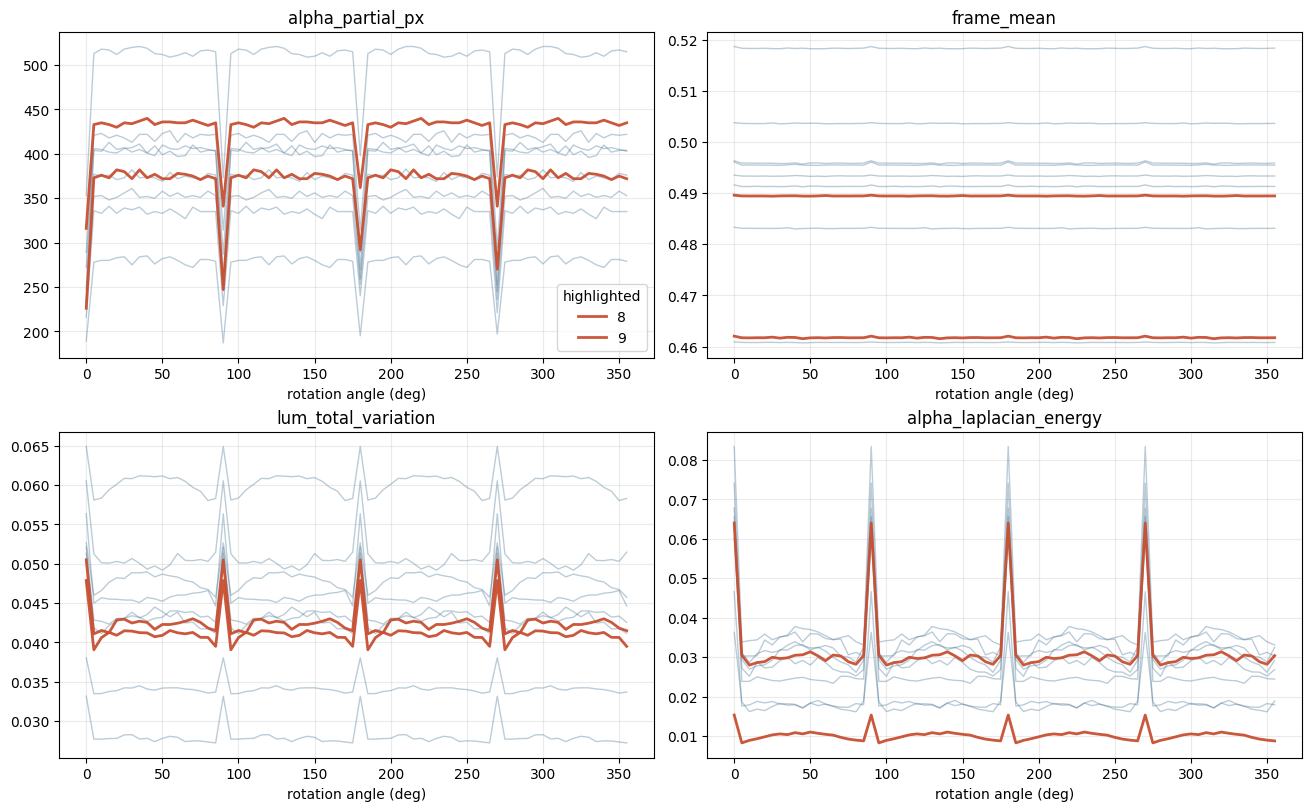

In [10]:
if not render_df.empty:
    metric_names = [
        "alpha_partial_px",
        "frame_mean",
        "lum_total_variation",
        "alpha_laplacian_energy",
    ]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    for ax, metric in zip(axes.ravel(), metric_names):
        for sprite in range(10):
            sub = render_df[render_df["sprite"] == sprite]
            color = "#c84f31" if sprite >= 8 else "#3f6f8f"
            alpha_line = 0.95 if sprite >= 8 else 0.35
            lw = 2.0 if sprite >= 8 else 1.0
            ax.plot(sub["angle"], sub[metric], color=color, alpha=alpha_line, lw=lw, label=str(sprite) if sprite >= 8 else None)
        ax.set_title(metric)
        ax.set_xlabel("rotation angle (deg)")
        ax.grid(True, alpha=0.25)
    axes[0, 0].legend(title="highlighted")
    plt.show()


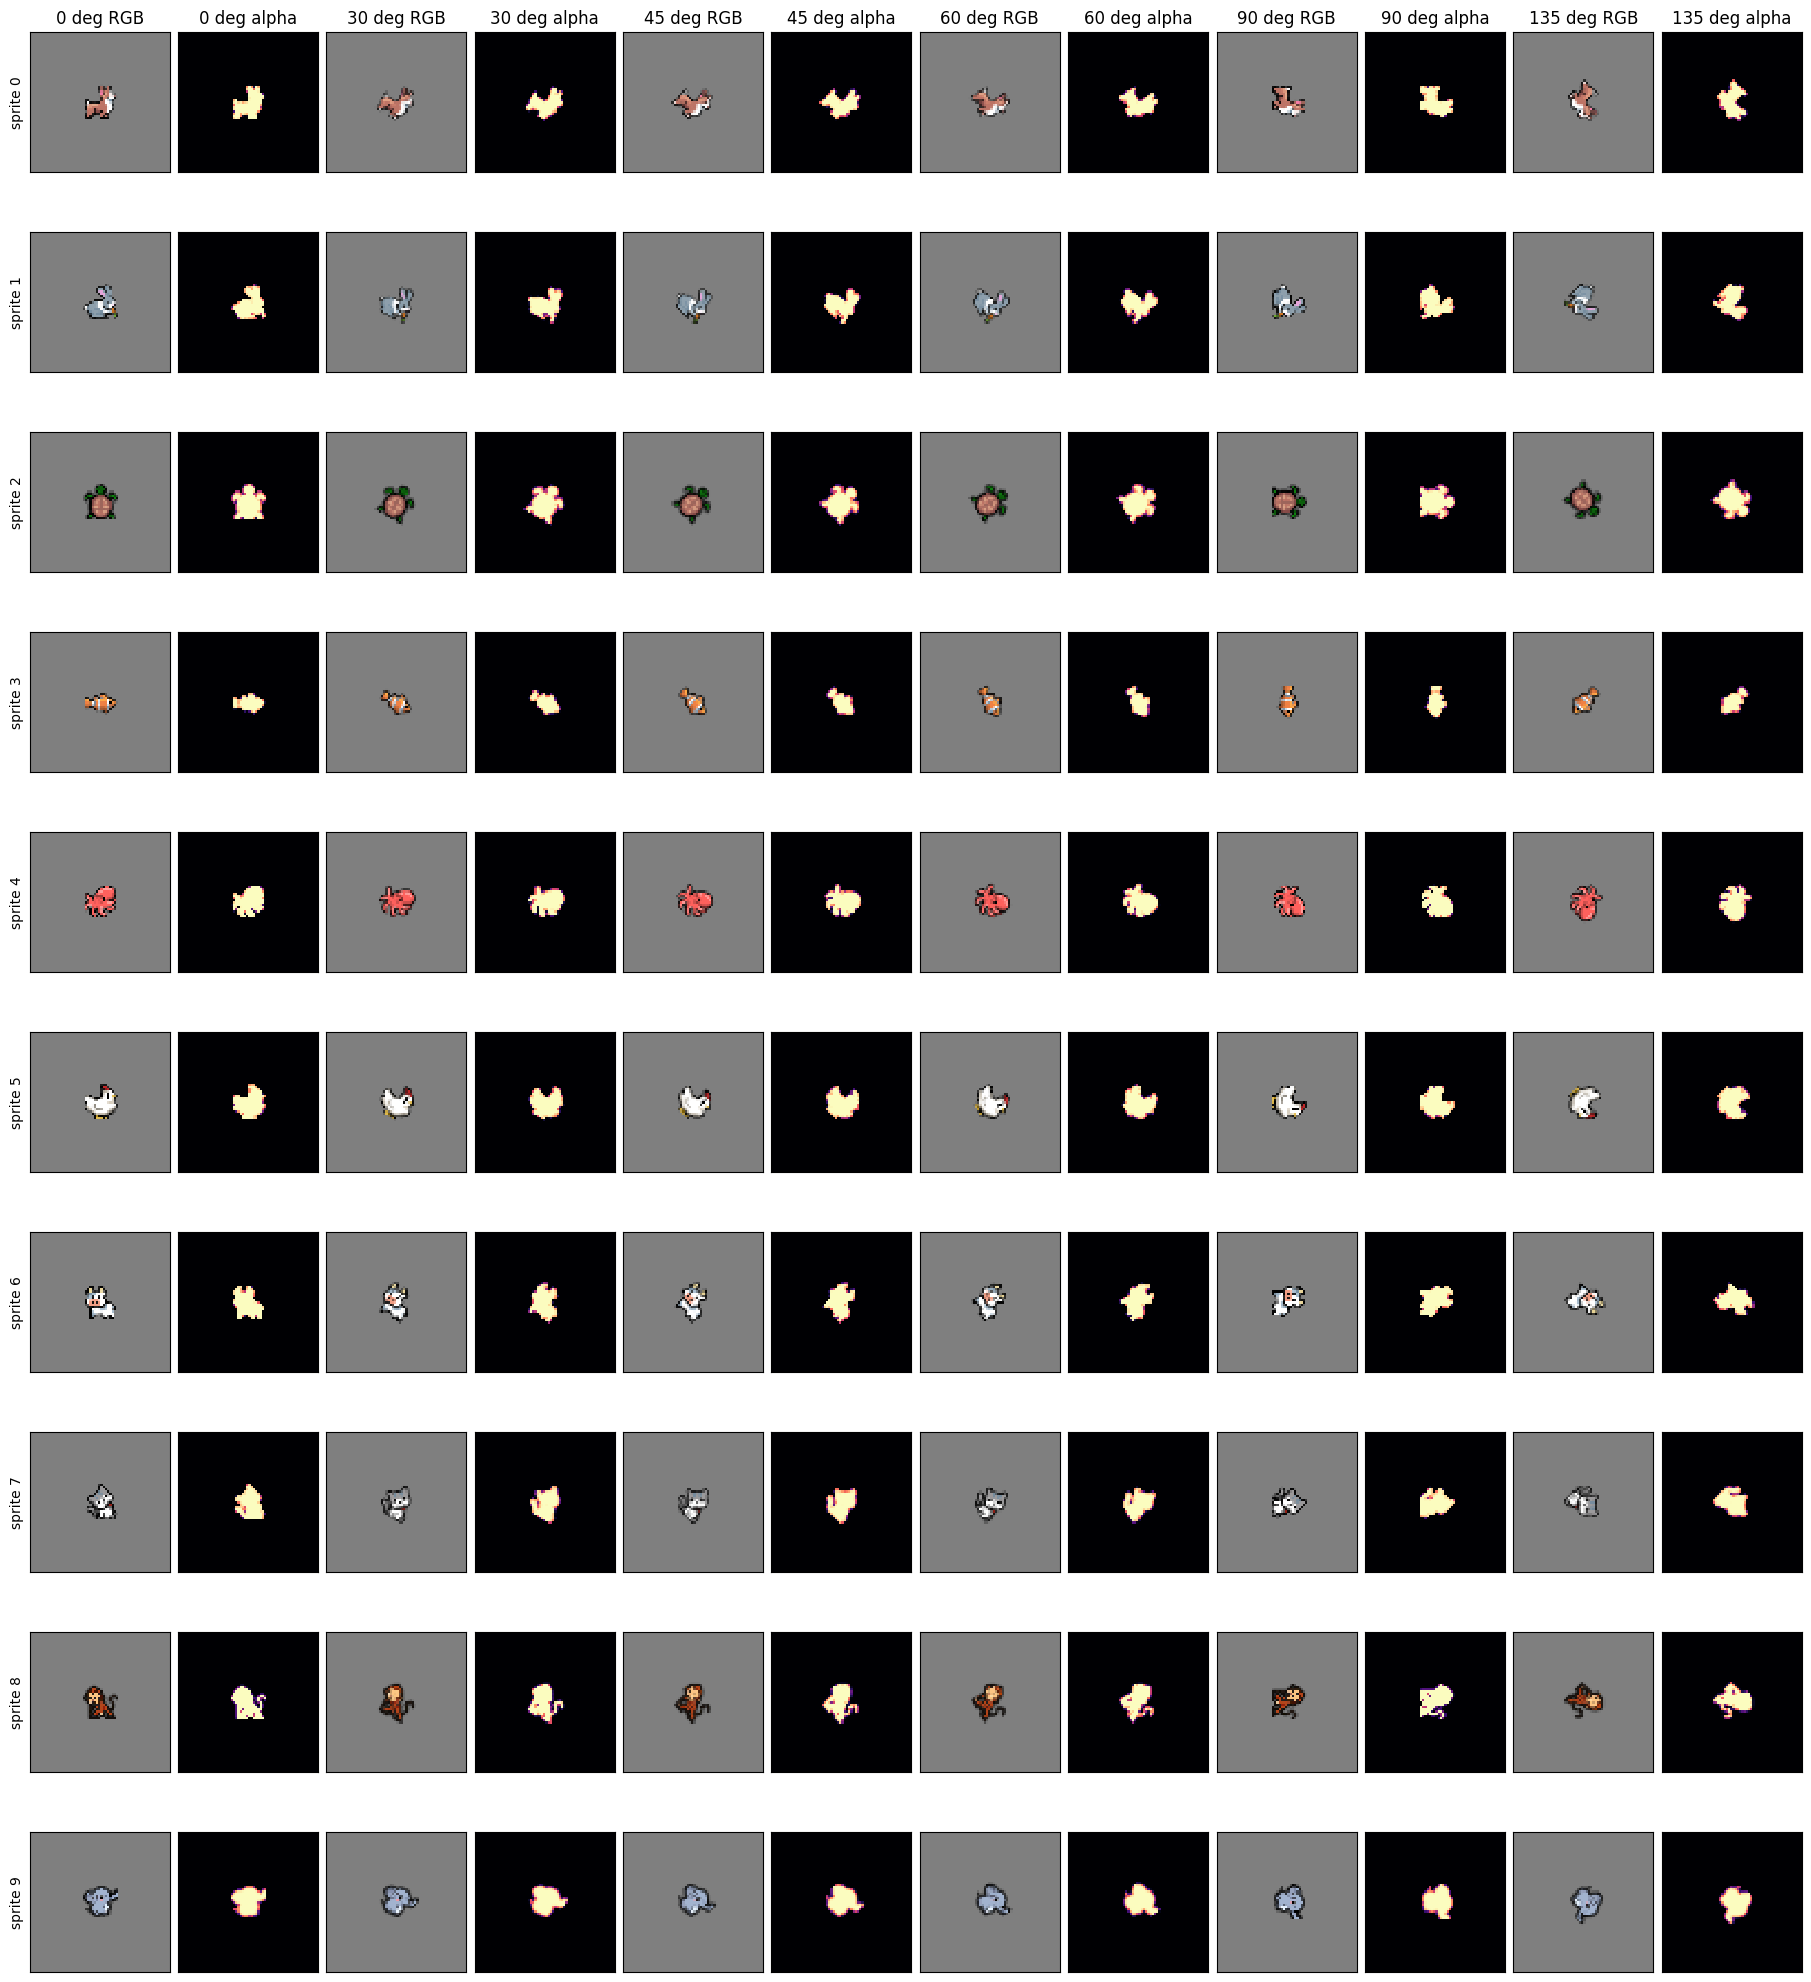

In [16]:
if torch is not None and K is not None:
    selected_angles = [0, 30, 45, 60, 90, 135]
    fig, axes = plt.subplots(len(SPRITE_PATHS), len(selected_angles) * 2, figsize=(18, 20), constrained_layout=True)
    for row, path in enumerate(SPRITE_PATHS):
        frames, alpha = render_sprite_batch(path, selected_angles, scale = 0.5)
        for j, angle in enumerate(selected_angles):
            axes[row, 2 * j].imshow(frames[j].transpose(1, 2, 0), interpolation="nearest", vmin=0, vmax=1)
            axes[row, 2 * j + 1].imshow(alpha[j, 0], cmap="magma", vmin=0, vmax=1, interpolation="nearest")
            if row == 0:
                axes[row, 2 * j].set_title(f"{angle} deg RGB")
                axes[row, 2 * j + 1].set_title(f"{angle} deg alpha")
        axes[row, 0].set_ylabel(f"sprite {sprite_idx(path)}")
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()


## Grayscale Loader Check

If the dataset is run with `grayscale=True`, `SpriteVideoDataset._pil_to_tensor` first composites RGBA onto black, converts that RGB image to luminance, and keeps alpha as a separate channel. This check shows what each sprite would look like through that grayscale path and reports contrast/edge statistics, so we can see whether normalizing `8-9` created grayscale-specific outliers.


,sprite,group,gray_visible_mean,gray_visible_std,gray_partial_mean,composite_mean,composite_std,composite_tv,composite_lap_energy
0,0,0-7,0.392795,0.334234,0.061880,0.485659,0.212773,0.208564,0.316625
1,1,0-7,0.404027,0.314454,0.102937,0.481969,0.204192,0.209465,0.283965
2,2,0-7,0.247059,0.206490,0.089140,0.351327,0.186925,0.154145,0.085566
3,3,0-7,0.376521,0.320471,0.079522,0.479773,0.166467,0.139337,0.182057
4,4,0-7,0.333852,0.269730,0.030913,0.427323,0.194468,0.226334,0.274736
5,5,0-7,0.568598,0.422730,0.096292,0.577703,0.306566,0.212757,0.289909
6,6,0-7,0.477651,0.424522,0.061226,0.515844,0.300774,0.264018,0.460126
7,7,0-7,0.382631,0.359703,0.108756,0.465804,0.249999,0.243358,0.332341
8,8,8-9,0.196227,0.258385,0.001452,0.355098,0.220497,0.205964,0.311904
9,9,8-9,0.358441,0.315166,0.058811,0.450995,0.211446,0.184256,0.207761


sprite         gray_visible_mean                     gray_visible_std                     gray_partial_mean                     composite_mean                     composite_std            \
        mean min max              mean       min       max             mean       min       max              mean       min       max           mean       min       max          mean       min   
group                                                                                                                                                                                              
0-7      3.5   0   7          0.397892  0.247059  0.568598         0.331542  0.206490  0.424522          0.078833  0.030913  0.108756       0.473175  0.351327  0.577703      0.227771  0.166467   
8-9      8.5   8   9          0.277334  0.196227  0.358441         0.286776  0.258385  0.315166          0.030132  0.001452  0.058811       0.403047  0.355098  0.450995      0.215971  0.211446   

                composite_tv                     composite_lap_energy                      
            max         mean       min       max                 mean       min       max  
group                                                                                      
0-7    0.306566     0.207247  0.139337  0.264018             0.278166  0.085566  0.460126  
8-9    0.220497     0.195110  0.184256  0.205964             0.259832  0.207761  0.311904

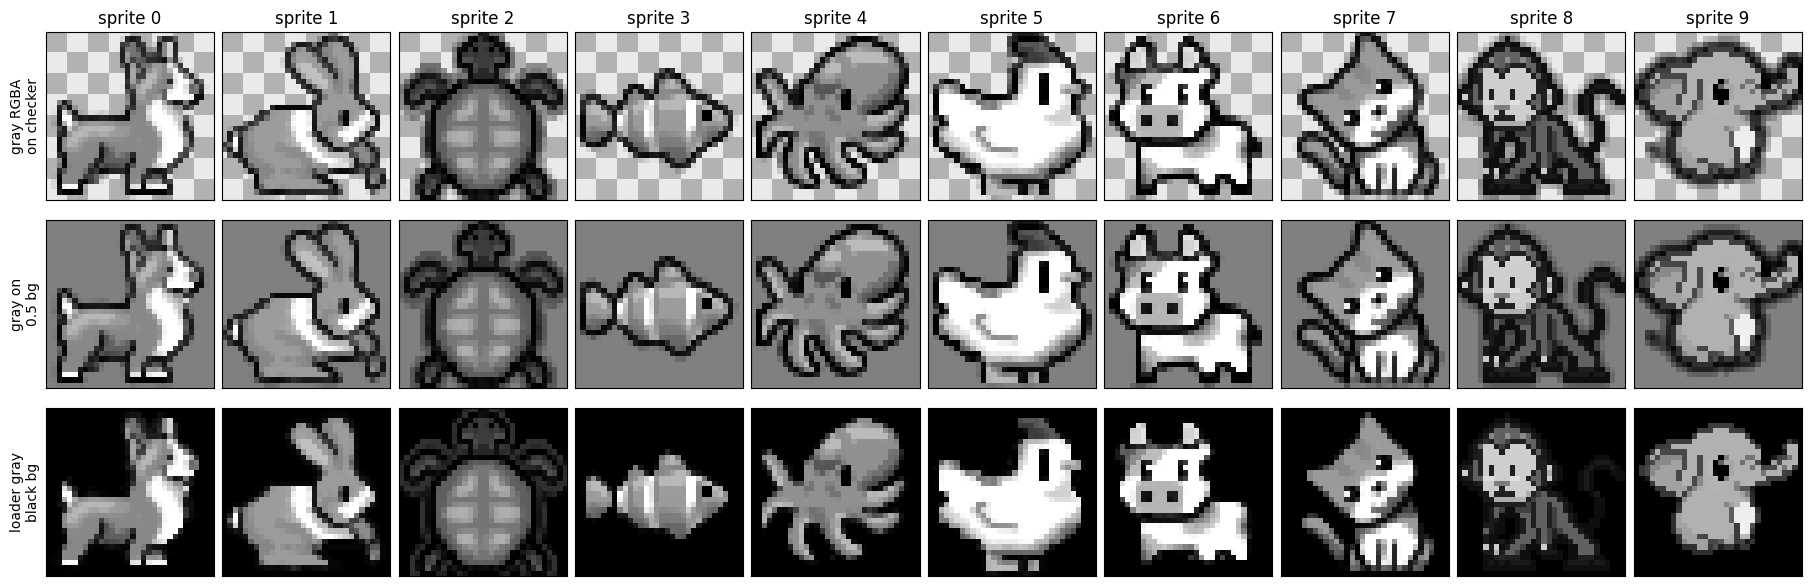

In [12]:
def load_loader_grayscale_np(path: Path) -> np.ndarray:
    """Return [2, H, W] grayscale+alpha as SpriteVideoDataset creates it."""
    pil_img = Image.open(path).convert("RGBA")
    alpha = pil_img.split()[3]
    rgb = Image.new("RGB", pil_img.size, (0, 0, 0))
    rgb.paste(pil_img, mask=alpha)
    gray = np.asarray(rgb.convert("L"), dtype=np.float32) / 255.0
    alpha_np = np.asarray(alpha, dtype=np.float32) / 255.0
    return np.stack([gray, alpha_np], axis=0)


def composite_gray_on_background(gray, alpha, background=0.5):
    return alpha * gray + (1 - alpha) * background


gray_rows = []
for path in SPRITE_PATHS:
    idx = sprite_idx(path)
    gray_alpha = load_loader_grayscale_np(path)
    gray = gray_alpha[0]
    alpha = gray_alpha[1]
    visible = alpha > 0
    partial = (alpha > 0) & (alpha < 1)
    comp = composite_gray_on_background(gray, alpha)

    gray_rows.append({
        "sprite": idx,
        "group": "8-9" if idx >= 8 else "0-7",
        "gray_visible_mean": float(gray[visible].mean()) if visible.any() else np.nan,
        "gray_visible_std": float(gray[visible].std()) if visible.any() else np.nan,
        "gray_partial_mean": float(gray[partial].mean()) if partial.any() else np.nan,
        "composite_mean": float(comp.mean()),
        "composite_std": float(comp.std()),
        "composite_tv": total_variation(comp[None, None]),
        "composite_lap_energy": laplacian_energy(comp[None, None]),
    })

gray_df = pd.DataFrame(gray_rows)
display(gray_df)
display(gray_df.groupby("group").agg(["mean", "min", "max"], numeric_only=True))

fig, axes = plt.subplots(3, len(SPRITE_PATHS), figsize=(18, 5.8), constrained_layout=True)
for col, path in enumerate(SPRITE_PATHS):
    gray_alpha = load_loader_grayscale_np(path)
    gray = gray_alpha[0]
    alpha = gray_alpha[1]
    comp_gray = composite_gray_on_background(gray, alpha)
    comp_checker = alpha[..., None] * np.repeat(gray[..., None], 3, axis=2) + (1 - alpha[..., None]) * checkerboard(gray.shape)

    axes[0, col].imshow(comp_checker, interpolation="nearest", vmin=0, vmax=1)
    axes[0, col].set_title(f"sprite {sprite_idx(path)}")
    axes[1, col].imshow(comp_gray, cmap="gray", interpolation="nearest", vmin=0, vmax=1)
    axes[2, col].imshow(gray, cmap="gray", interpolation="nearest", vmin=0, vmax=1)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axes[0, 0].set_ylabel("gray RGBA\non checker")
axes[1, 0].set_ylabel("gray on\n0.5 bg")
axes[2, 0].set_ylabel("loader gray\nblack bg")
plt.show()


## Interpretation

The strongest low-level difference is alpha-mask style:

- Sprites `0-7` have antialiased alpha masks with many alpha levels and hundreds of semi-transparent pixels.
- Sprites `8-9` have binary alpha masks only, with no semi-transparent pixels in the source PNGs.
- After affine rotation, binary masks produce different edge and area stability statistics from the softer masks.

The raw hidden RGB background also differs:

- Sprites `0-7`: transparent pixels have black RGB.
- Sprites `8-9`: transparent pixels have white RGB.
- The current HARPL sprite loaders remove this cue by compositing onto black before training, but any alternate direct-RGBA loader would expose it.

Practical follow-up experiments:

1. Re-export sprites `8-9` with antialiased alpha masks matching `0-7`.
2. Or threshold all sprites `0-7` to binary alpha, making the whole set stylistically uniform.
3. Strip PNG metadata and force transparent RGB to black for all sprites.
4. Re-run the RPL comparison with normalized sprite assets. If performance recovers, the training drop was likely caused by asset export style rather than semantic animal identity.
